In [1]:
import os
import sys
from pathlib import Path

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN, ResNet
from trainer import train, evaluate



In [2]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [3]:
train_loader, val_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"],
    augment=cfg["train"]["augment"],
    val_split_seed=cfg["train"]["val_split_seed"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 704
Number of validation batches: 79
Number of testing batches: 157


In [4]:
plain_cnn = PlainCNN(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_optimizer = torch.optim.Adam(plain_cnn.parameters(), lr=1e-3)

resnet = ResNet(num_classes=cfg["model"]["num_classes"]).to(device)
resnet_optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

# print(plain_cnn)
print(f"Number of parameters (Plain CNN): {sum(p.numel() for p in plain_cnn.parameters()):,}")
# print(resnet)
print(f"Number of parameters (ResNet): {sum(p.numel() for p in resnet.parameters()):,}")

Number of parameters (Plain CNN): 289,194
Number of parameters (ResNet): 299,530


[10:19:05] Epoch 01/30
Train: [1.3271, 0.5179] | Val: [1.3215, 0.5460] | 23.85s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.5460

[10:19:29] Epoch 02/30
Train: [0.9350, 0.6707] | Val: [0.9987, 0.6562] | 36.38s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.6562

[10:20:05] Epoch 03/30
Train: [0.7773, 0.7282] | Val: [0.8733, 0.7008] | 34.21s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7008

[10:20:40] Epoch 04/30
Train: [0.6807, 0.7630] | Val: [0.7634, 0.7412] | 33.62s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7412

[10:21:13] Epoch 05/30
Train: [0.6217, 0.7845] | Val: [0.6259, 0.7818] | 32.22s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7818

[10:21:45] Epoch 06/30
Train: [0.5760, 0.7997] | Val: [0.7516, 0.7424] | 32.93s

[10:22:18] Epoch 07/30
Train: [0.5359, 0.8145] | Val: [0.5753, 0.8108] | 32.98s
New best model saved at checkpoints\best_plain_cnn.pt with 

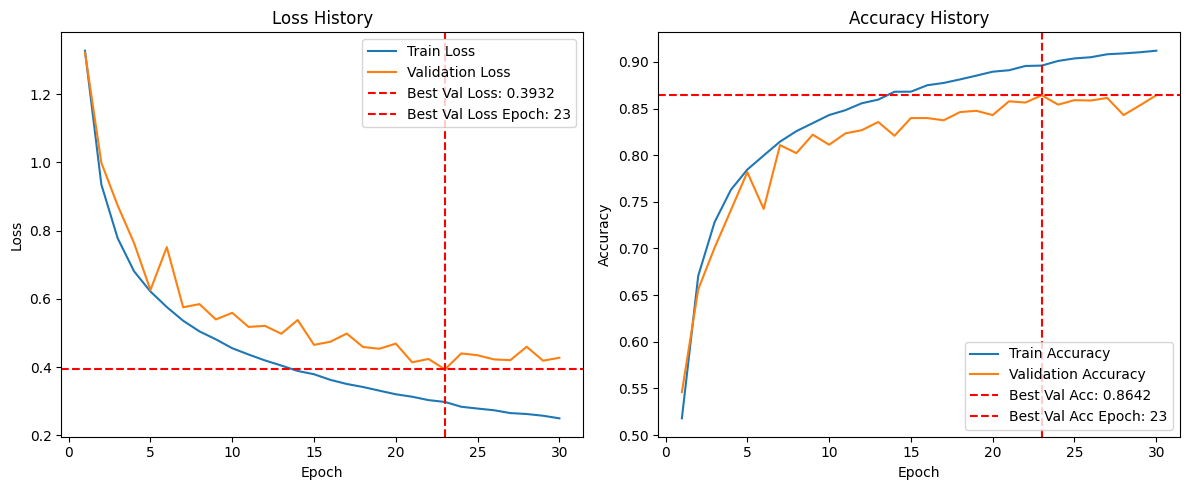

In [ ]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=plain_cnn,
    optimizer=plain_cnn_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_plain_cnn.pt"
)

plot_history(history, save_path=ckpt_dir / "history_plain_cnn.png", show=True)


In [6]:
print(f"Loading best model from {ckpt_dir / 'best_plain_cnn.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
plain_cnn.load_state_dict(torch.load(ckpt_dir / "best_plain_cnn.pt"))

test_loss, test_acc = evaluate(plain_cnn, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_plain_cnn.pt
Best Val Loss: 0.3932 | Best Val Acc: 0.8642
Test Loss: 0.4233 | Test Acc: 0.8625


[10:32:14] Epoch 01/30
Train: [1.4126, 0.4816] | Val: [1.3941, 0.5000] | 19.27s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.5000

[10:32:33] Epoch 02/30
Train: [1.0583, 0.6217] | Val: [1.0100, 0.6418] | 18.55s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.6418

[10:32:52] Epoch 03/30
Train: [0.9148, 0.6762] | Val: [0.8503, 0.7072] | 16.46s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7072

[10:33:08] Epoch 04/30
Train: [0.8178, 0.7136] | Val: [0.7986, 0.7154] | 15.26s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7154

[10:33:23] Epoch 05/30
Train: [0.7387, 0.7409] | Val: [0.7488, 0.7384] | 15.12s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7384

[10:33:38] Epoch 06/30
Train: [0.6793, 0.7651] | Val: [0.6859, 0.7508] | 15.05s
New best model saved at checkpoints\best_resnet.pt with val_acc: 0.7508

[10:33:53] Epoch 07/30
Train: [0.6360, 0.7802] | Val: [0.6413, 0.7668] | 15.20s
Ne

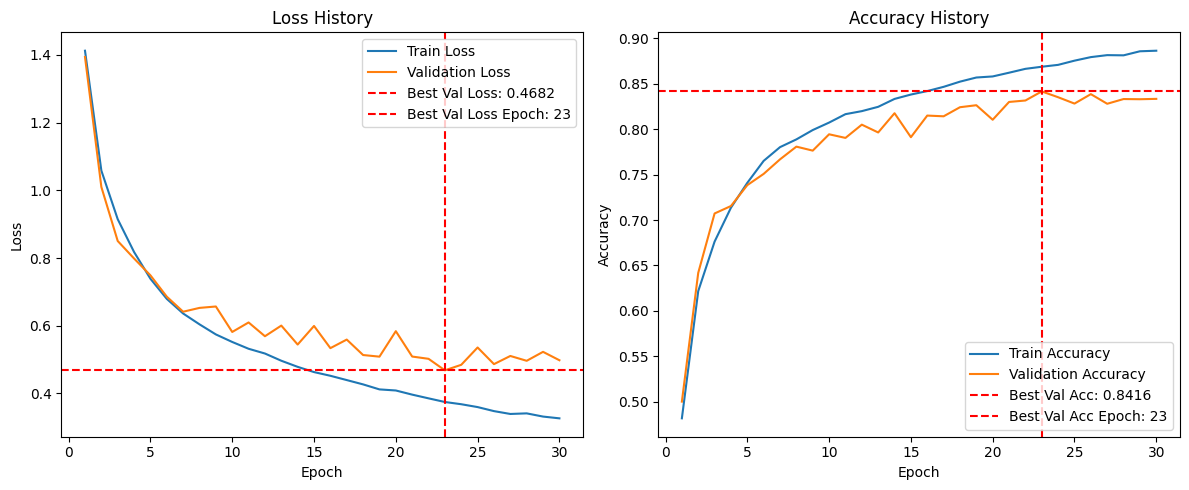

In [7]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=resnet,
    optimizer=resnet_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir,
    save_name="best_resnet.pt"
)

plot_history(history, save_path=ckpt_dir / "history_resnet.png", show=True)


In [8]:
print(f"Loading best model from {ckpt_dir / 'best_resnet.pt'}")
print(f"Best Val Loss: {min(history['val_loss']):.4f} | Best Val Acc: {max(history['val_acc']):.4f}")
resnet.load_state_dict(torch.load(ckpt_dir / "best_resnet.pt"))

test_loss, test_acc = evaluate(resnet, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model from checkpoints\best_resnet.pt
Best Val Loss: 0.4682 | Best Val Acc: 0.8416
Test Loss: 0.5011 | Test Acc: 0.8330
